# 0. Imports and Setup

In [1]:
import numpy as np
import torch
import torch.nn as nn
import pandas as pd
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.svm import SVC
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.ensemble import RandomForestClassifier
sns.set_style('whitegrid')

# 1. Data Preprocessing

## 1.1 EDA and Data Cleaning

Dataset Shape:
 (351, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 351 entries, 0 to 350
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   student_id       351 non-null    int64  
 1   hours_studied    351 non-null    float64
 2   sleep_hours      341 non-null    float64
 3   attendance_rate  341 non-null    float64
 4   prev_exam_score  341 non-null    float64
 5   lucky_number     351 non-null    int64  
 6   exam_score       351 non-null    float64
 7   passed           351 non-null    int64  
dtypes: float64(5), int64(3)
memory usage: 22.1 KB

Dataset Types:
 None

Dataset Description:
        student_id  hours_studied  sleep_hours  attendance_rate  \
count  351.000000     351.000000   341.000000        341.00000   
mean   176.000000       6.394587     6.441642         69.78827   
std    101.469207       3.208560     2.139522         17.96527   
min      1.000000       1.100000    -2.000000      

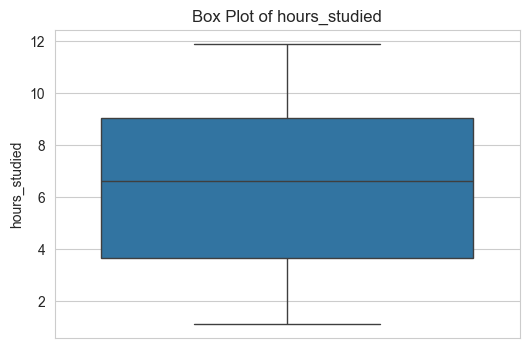

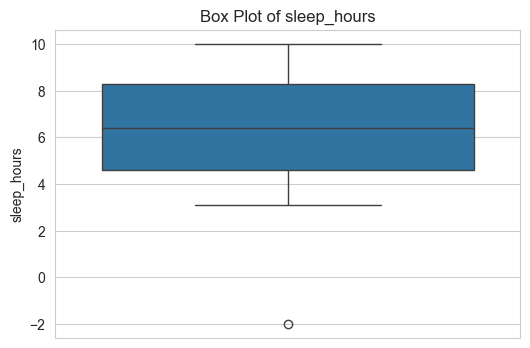

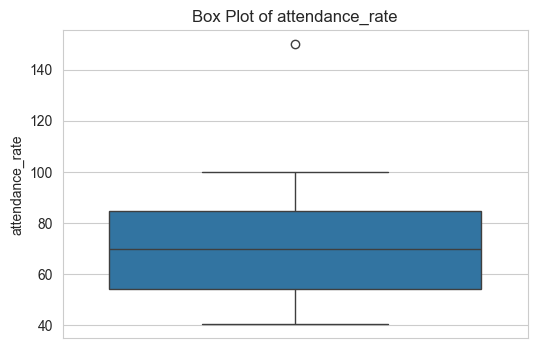

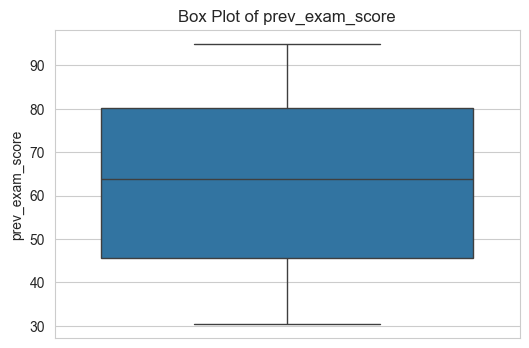

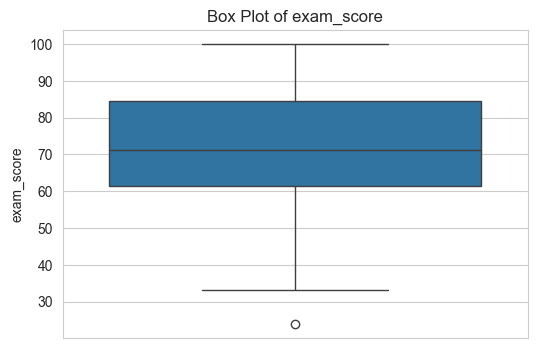


Impossible Values:


Hours Studied < 0:
 Empty DataFrame
Columns: [student_id, hours_studied, sleep_hours, attendance_rate, prev_exam_score, lucky_number, exam_score, passed]
Index: []

Sleep Hours < 0:
      student_id  hours_studied  sleep_hours  attendance_rate  prev_exam_score  \
304         305            9.0         -2.0             88.4             61.6   

     lucky_number  exam_score  passed  
304            42        67.1       1  

Attendance Rate < 0 or > 100:
     student_id  hours_studied  sleep_hours  attendance_rate  prev_exam_score  \
89          90            6.2          3.6            150.0             68.5   

    lucky_number  exam_score  passed  
89            69        62.3       0  

Previous Exam Score < 0 or > 100:
 Empty DataFrame
Columns: [student_id, hours_studied, sleep_hours, attendance_rate, prev_exam_score, lucky_number, exam_score, passed]
Index: []

Exam Score < 0 or > 100:
 Empty DataFrame
Columns: [student_id, hours_studied, sleep_hours, attendan

C:\Users\gcisn\AppData\Local\Temp\ipykernel_13856\3416897791.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train, x='passed', palette='Set2')


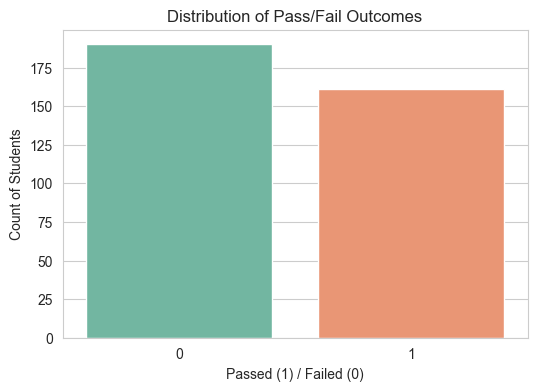

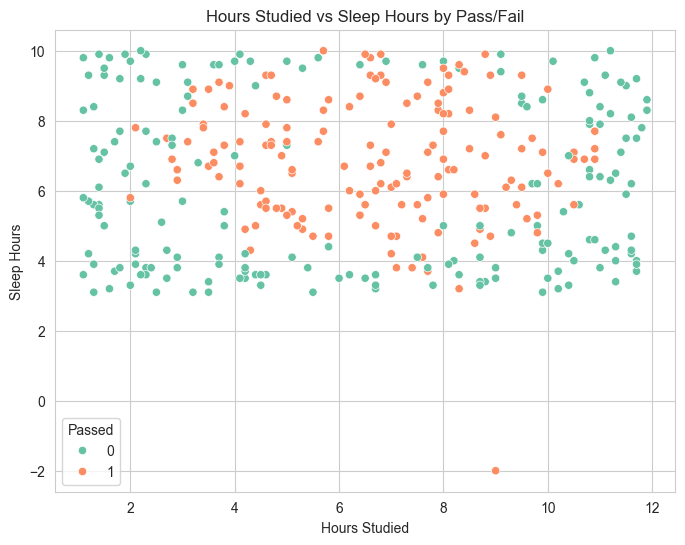

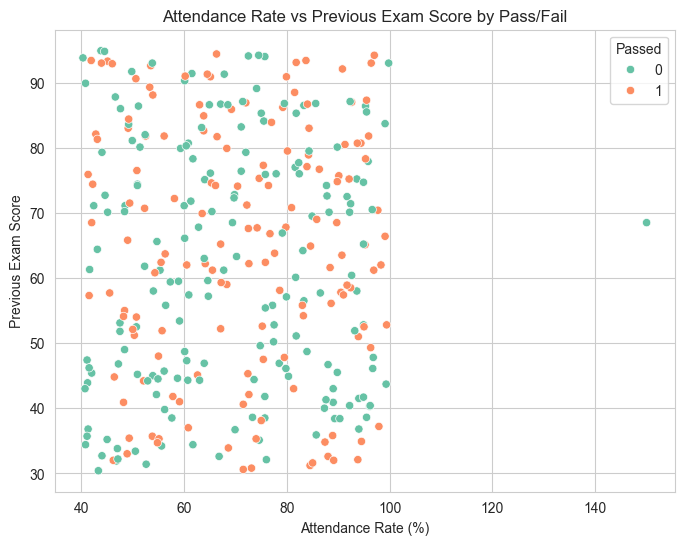

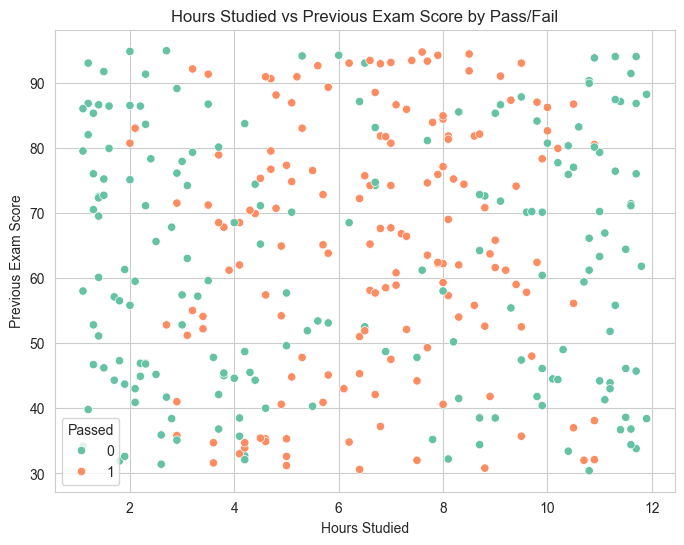

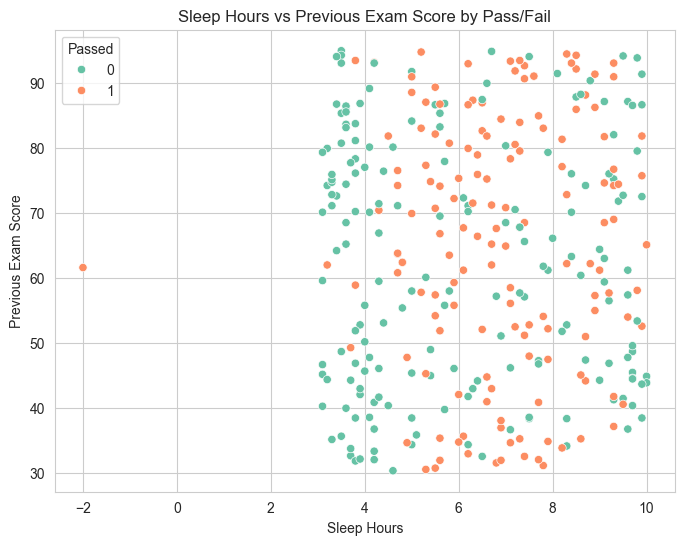

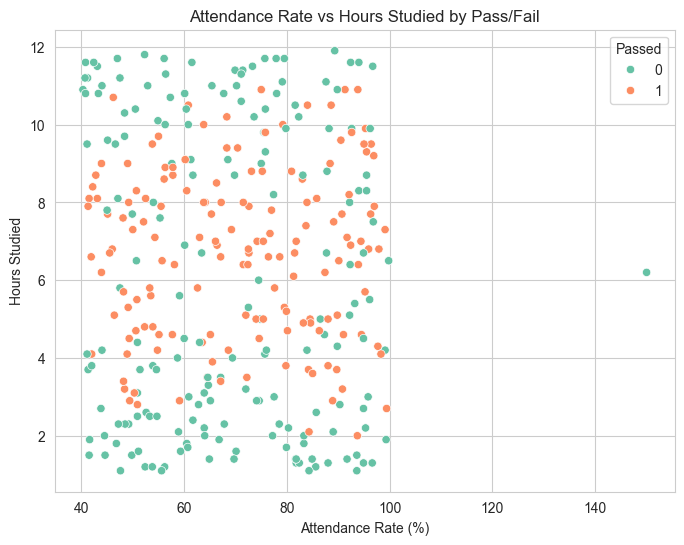

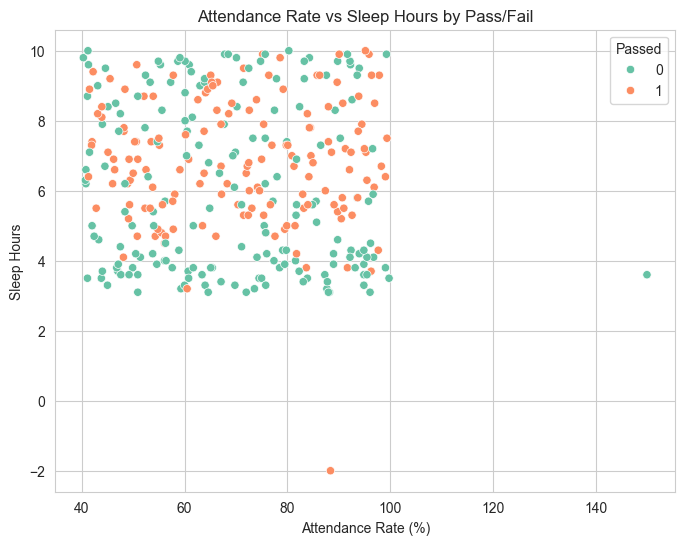

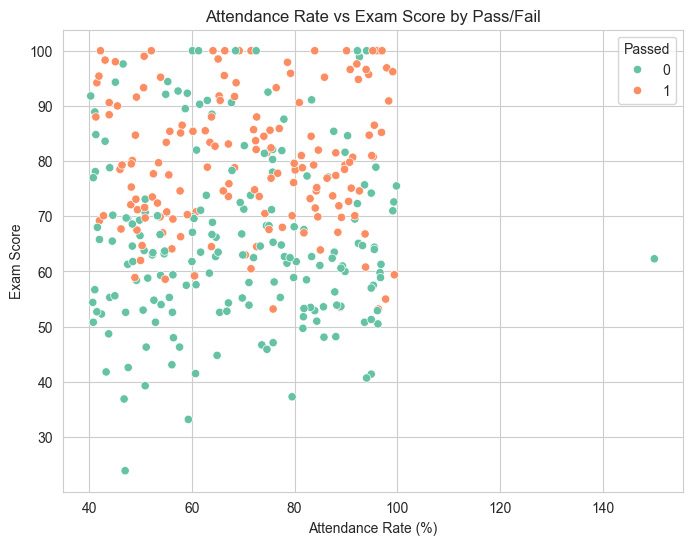


Row Count After Dropping Duplicates: student_id         351
hours_studied      351
sleep_hours        341
attendance_rate    341
prev_exam_score    341
lucky_number       351
exam_score         351
passed             351
dtype: int64

Row Count After Dropping Impossible Values: student_id         320
hours_studied      320
sleep_hours        320
attendance_rate    320
prev_exam_score    320
lucky_number       320
exam_score         320
passed             320
dtype: int64

Median Values for Imputation:
 student_id         175.50
hours_studied        6.60
sleep_hours          6.40
attendance_rate     70.30
prev_exam_score     64.00
lucky_number        47.00
exam_score          71.55
passed               0.00
dtype: float64


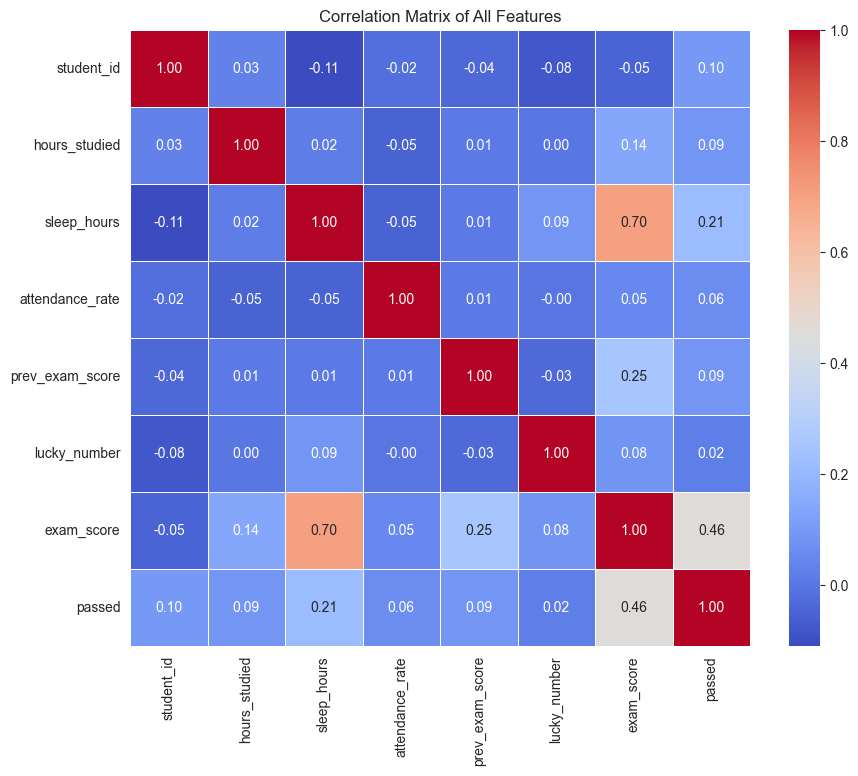

In [2]:
train = pd.read_csv('p2_train.csv')
test = pd.read_csv('p2_test.csv')

print("Dataset Shape:\n", train.shape)
print("\nDataset Types:\n", train.info())
print("\nDataset Description:\n", train.describe())
print("\nDataset Dtype:\n", train.dtypes)

# Check for missing values
print("\nMissing Values:\n", train.isnull().sum())
# Check for duplicates
print("\nDuplicate Rows:\n", train.duplicated().sum())
# Check for outliers using boxplot
features = ['hours_studied', 'sleep_hours', 'attendance_rate', 'prev_exam_score', 'exam_score']
for i, col in enumerate(features):
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=train[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
    plt.show()

#Check for Impossible Values
print("\nImpossible Values:\n")
print("\nHours Studied < 0:\n", train[train['hours_studied'] < 0])
print("\nSleep Hours < 0:\n", train[train['sleep_hours'] < 0])
print("\nAttendance Rate < 0 or > 100:\n", train[(train['attendance_rate'] < 0) | (train['attendance_rate'] > 100)])
print("\nPrevious Exam Score < 0 or > 100:\n", train[(train['prev_exam_score'] < 0) | (train['prev_exam_score'] > 100)])
print("\nExam Score < 0 or > 100:\n", train[(train['exam_score'] < 0) | (train['exam_score'] > 100)])



# Count Plot
plt.figure(figsize=(6, 4))
sns.countplot(data=train, x='passed', palette='Set2')
plt.title("Distribution of Pass/Fail Outcomes")
plt.xlabel("Passed (1) / Failed (0)")
plt.ylabel("Count of Students")
plt.show()

# Scatter Plots
plt.figure(figsize=(8, 6))
sns.scatterplot(data=train, x='hours_studied', y='sleep_hours', hue='passed', palette='Set2')
plt.title("Hours Studied vs Sleep Hours by Pass/Fail")
plt.xlabel("Hours Studied")
plt.ylabel("Sleep Hours")
plt.legend(title='Passed')
plt.show()
plt.figure(figsize=(8, 6))
sns.scatterplot(data=train, x='attendance_rate', y='prev_exam_score', hue='passed', palette='Set2')
plt.title("Attendance Rate vs Previous Exam Score by Pass/Fail")
plt.xlabel("Attendance Rate (%)")
plt.ylabel("Previous Exam Score")
plt.legend(title='Passed')
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=train, x='hours_studied', y='prev_exam_score', hue='passed', palette='Set2')
plt.title("Hours Studied vs Previous Exam Score by Pass/Fail")
plt.xlabel("Hours Studied")
plt.ylabel("Previous Exam Score")
plt.legend(title='Passed')
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=train, x='sleep_hours', y='prev_exam_score', hue='passed', palette='Set2')
plt.title("Sleep Hours vs Previous Exam Score by Pass/Fail")
plt.xlabel("Sleep Hours")
plt.ylabel("Previous Exam Score")
plt.legend(title='Passed')
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=train, x='attendance_rate', y='hours_studied', hue='passed', palette='Set2')
plt.title("Attendance Rate vs Hours Studied by Pass/Fail")
plt.xlabel("Attendance Rate (%)")
plt.ylabel("Hours Studied")
plt.legend(title='Passed')
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=train, x='attendance_rate', y='sleep_hours', hue='passed', palette='Set2')
plt.title("Attendance Rate vs Sleep Hours by Pass/Fail")
plt.xlabel("Attendance Rate (%)")
plt.ylabel("Sleep Hours")
plt.legend(title='Passed')
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=train, x='attendance_rate', y='exam_score', hue='passed', palette='Set2')
plt.title("Attendance Rate vs Exam Score by Pass/Fail")
plt.xlabel("Attendance Rate (%)")
plt.ylabel("Exam Score")
plt.legend(title='Passed')
plt.show()


#Data Cleaning
#Drop duplicates
train = train.drop_duplicates()
print("\nRow Count After Dropping Duplicates:", train.count())


# Drop rows with missing values
# train = train.dropna()
# print("\nRow Count After Dropping Missing Values:", train.count())

# Drops rows with impossible values
train = train[(train['hours_studied'] >= 0) & (train['sleep_hours'] >= 0) & 
                (train['attendance_rate'] >= 0) & (train['attendance_rate'] <= 100) & 
                (train['prev_exam_score'] >= 0) & (train['prev_exam_score'] <= 100) & 
                (train['exam_score'] >= 0) & (train['exam_score'] <= 100)]
print("\nRow Count After Dropping Impossible Values:", train.count())

# Data Imputation
train_median = train.median()
print("\nMedian Values for Imputation:\n", train_median)
train = train.fillna(train_median)


# Prints correlation matrix
correlation_data = train
correlation_matrix = correlation_data.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of All Features")
plt.show()


Quality:
This time for the data cleaning, data imputation was done for rows with missing data, since the rows that would have been dropped was going to be around 6% of the training data. Instead of dropping the rows, the median of each row replaced the missing data. The scatter plots that were created to check the linear separability of the data all show that the data is not linear separable. This result is because all the points, whether pass or fail, are too close together, making it too hard to linearly separate. It could be done, but would result in subpar results. Moreover, the correlation matrix emphasizes the small linear relationship each of the columns have with each other. The data emphasizes a burnout effect on some of the features, especially hours_studied.

## 1.2 Feature Selection and Normalization

In [3]:


selected_features = ['hours_studied', 'sleep_hours', 'attendance_rate', 'prev_exam_score']
x = train[selected_features]
y = train['passed']

x_test = test[selected_features]
y_test = test['passed']

# Calculate Z-Score for both train and test
train_zscore = (train[selected_features] - train[selected_features].mean()) / train[selected_features].std()
test_zscore = (test[selected_features] - train[selected_features].mean()) / train[selected_features].std()




Quality:
The following features were dropped, exam_score, student_id, and lucky_number. A students ID and lucky number have no logical connection to their pass rate on the exam. Moreover, using the exam_score can not be used to accurately train the model. The hours_studied, sleep_hours, attendance_rate, and prev_exam_score are leftover features. Each of these feature would logically affect a student's pass/fail performance on an exam. Therefore, these are the selected features for the model.

# 2. Baseline: Logistic Regression (sklearn)

In [4]:
logistic_regression_model = LogisticRegression()
logistic_regression_model.fit(train_zscore, y)



# Predict on train 
y_train_pred = logistic_regression_model.predict(train_zscore)
# Predict on test data
y_test_pred = logistic_regression_model.predict(test_zscore)

# Model Accuracy
train_accuracy = accuracy_score(y, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"\nTraining Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")
print("\nClassification Report (Train):\n", classification_report(y, y_train_pred))


importances = np.abs(logistic_regression_model.coef_[0])
top_indices = np.argsort(importances)[-2:]
top_feature_names = [selected_features[i] for i in top_indices]
def plot_decision_boundary(X, y, model_type, feature_indices, feature_names):
    # Fix: Convert X to a numpy array to allow [:, indices] slicing
    if hasattr(X, "values"):
        X_np = X.values
    else:
        X_np = X
        
    X_2d = X_np[:, feature_indices] 
    
    vis_model = model_type 
    vis_model.fit(X_2d, y)
    

    # Create coordinate grid
    grid_resolution = .02
    x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
    y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
    grid_x_coords, grid_y_coords = np.meshgrid(
        np.arange(x_min, x_max, grid_resolution), 
        np.arange(y_min, y_max, grid_resolution)
    )
    
    # Predict outcomes
    grid_predictions = vis_model.predict(np.c_[grid_x_coords.ravel(), grid_y_coords.ravel()])
    grid_predictions = grid_predictions.reshape(grid_x_coords.shape)
    
    # Plot figure
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, edgecolors='k', cmap='coolwarm', alpha=0.7)
    plt.title(f"Decision Boundary: {feature_names[0]} vs {feature_names[1]}")
    plt.xlabel(f"Scaled {feature_names[0]}")
    plt.ylabel(f"Scaled {feature_names[1]}")
    plt.show()

# Call the function using the top 2 features
plot_decision_boundary(x, y, LogisticRegression(), top_indices, top_feature_names)

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



Training Accuracy: 0.5594
Testing Accuracy: 0.5875

Classification Report (Train):
               precision    recall  f1-score   support

           0       0.58      0.69      0.63       175
           1       0.52      0.41      0.46       145

    accuracy                           0.56       320
   macro avg       0.55      0.55      0.54       320
weighted avg       0.55      0.56      0.55       320



NameError: name 'xx' is not defined

<Figure size 800x600 with 0 Axes>

Quality:
The training accuracy is much worse than my project 1 results. Logistic regression performs poorly here because of the nature of the data. As previously discussed, the data is not linearly separable, making it much harder for the model to have a high accuracy. The poor performance is not due to underfitting.

# 3. Decision Tree

## 3.1 NumPy Implementation (From Scratch)

In [ ]:
def gini_impurity(y):
    if len(y) == 0:
        return 0
    proportion = np.bincount(y) / len(y)
    return 1 - np.sum(proportion ** 2)

def information_gain(parent, left_child, right_child):
    weight_left = len(left_child) / len(parent)
    weight_right = len(right_child) / len(parent)
    gain = gini_impurity(parent) - (weight_left * gini_impurity(left_child) + weight_right * gini_impurity(right_child))
    return gain

# Creates a node class
class Node:
    def __init__(self, feature_index=None, threshold=None, left=None, right=None, value=None):
        self.feature_index = feature_index
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value
# Creates a decision tree class using the node class that was just created
class DecisionTree:
    def __init__(self, max_depth=5, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None
    
    def fit(self, X, y):
        self.root = self._build_tree(X, y, depth=0)

    def _build_tree(self, X, y, depth):
        num_samples, num_features = X.shape
        num_labels = len(np.unique(y))

        #Stopping condition
        if depth >= self.max_depth or num_labels == 1 or num_samples < self.min_samples_split:
            leaf_value = np.bincount(y).argmax()
            return Node(value=leaf_value)
        
        best_gain = -1
        best_feature_index = None
        best_threshold = None

        for feature_index in range(num_features):
            thresholds = np.unique(X[:, feature_index])
            for threshold in thresholds:
                left_indices = np.where(X[:, feature_index] <= threshold)[0]
                right_indices = np.where(X[:, feature_index] > threshold)[0]

                if len(left_indices) == 0 or len(right_indices) == 0:
                    continue

                gain = information_gain(y, y[left_indices], y[right_indices])

                if gain > best_gain:
                    best_gain = gain
                    best_feature_index = feature_index
                    best_threshold = threshold
                if best_feature_index is None:
                    leaf_value = np.bincount(y).argmax()
                    return Node(value=leaf_value)
                    
        left_indices = np.where(X[:, best_feature_index] <= best_threshold)[0]
        right_indices = np.where(X[:, best_feature_index] > best_threshold)[0]
        left_child = self._build_tree(X[left_indices], y[left_indices], depth + 1)
        right_child = self._build_tree(X[right_indices], y[right_indices], depth + 1)
        return Node(feature_index=best_feature_index, threshold=best_threshold, left=left_child, right=right_child)
    
    def predict(self, X):
        return np.array([self._traverse_tree_(x, self.root) for x in X])
    
    def _traverse_tree_(self, x, node):
        if node.value is not None:
            return node.value
        if x[node.feature_index] <= node.threshold:
            return self._traverse_tree_(x, node.left)
        else:
            return self._traverse_tree_(x, node.right)
        
    def _print_tree_(self, node, depth=0):
        if node.value is not None:
            print(f"{' ' * depth * 4}Leaf: Class={node.value}")
        else:
            
            print(f"{' ' * depth * 4}Feature: {selected_features[node.feature_index]} <= {node.threshold:.4f}")
            self._print_tree_(node.left, depth + 1)
            self._print_tree_(node.right, depth + 1)


# Test on Toy Dataset before real dataset
x_toy = np.array([[1, 2], [2, 1], [10, 10], [11, 11]])
y_toy = np.array([0, 0, 1, 1])
toy_tree = DecisionTree(max_depth=2)
toy_tree.fit(x_toy, y_toy)
print("Decision Tree Structure:")
toy_tree._print_tree_(toy_tree.root)

toy_prediction = toy_tree.predict(x_toy)
print("\nToy Dataset Predictions:", toy_prediction)
print("\nToy Accuracy:")
print(np.mean(toy_prediction == y_toy)*100, "%")

# Train on real dataset
real_tree = DecisionTree(max_depth=5)
real_tree.fit(train_zscore.values, y.values)
real_predictions = real_tree.predict(train_zscore.values)
print("\nReal Dataset Predictions:\n", real_predictions)
print("\nReal Accuracy:")
print(np.mean(real_predictions == y.values)*100, "%")
print("\nTree Structure for Actual Dataset:")
real_tree._print_tree_(real_tree.root)

        



        



Decision Tree Structure:
Feature: hours_studied <= 2.0000
    Leaf: Class=0
    Leaf: Class=1

Toy Dataset Predictions: [0 0 1 1]

Toy Accuracy:
100.0 %

Real Dataset Predictions:
 [1 0 1 0 1 0 1 0 1 1 0 1 1 0 0 0 1 0 0 1 0 0 1 0 1 1 0 1 0 0 0 0 0 1 1 0 1
 1 0 1 0 0 1 0 1 1 0 0 1 0 0 0 0 0 0 1 0 0 1 1 1 0 1 0 0 1 1 0 1 0 1 0 1 0
 0 1 1 0 0 1 0 1 0 0 0 1 1 1 0 0 0 0 0 1 1 1 0 1 0 1 0 0 0 0 0 1 0 0 1 0 0
 0 0 0 0 0 1 0 0 1 0 1 1 1 0 1 0 1 0 1 0 0 0 1 1 1 0 1 0 0 0 1 1 0 0 0 1 1
 0 1 0 0 1 0 0 0 0 0 1 1 1 1 1 1 0 0 1 0 1 1 1 0 0 0 0 1 1 1 0 1 0 1 1 0 1
 0 0 0 0 0 1 1 0 0 1 1 1 1 1 1 1 1 1 0 0 0 1 1 0 1 1 1 1 0 0 0 0 0 0 1 0 0
 1 0 0 0 0 1 0 0 0 1 0 1 1 1 0 0 0 0 0 0 1 1 0 0 1 0 1 1 1 1 0 1 0 1 1 0 1
 0 1 1 1 1 0 0 1 0 1 1 1 1 0 1 1 1 0 1 1 1 1 1 0 0 0 0 0 1 0 0 1 1 1 0 1 0
 0 0 1 0 1 1 0 0 0 0 1 1 0 1 1 0 1 0 1 1 0 0 1 1]

Real Accuracy:
90.0 %

Tree Structure for Actual Dataset:
Feature: sleep_hours <= -0.8840
    Feature: prev_exam_score <= 1.5528
        Feature: attendance_rate <= 1.5

## 3.2 sklearn Verification


Scikit-learn Decision Tree Training Accuracy: 90.00%

Numpy Decision Tree Training Accuracy: 90.00%


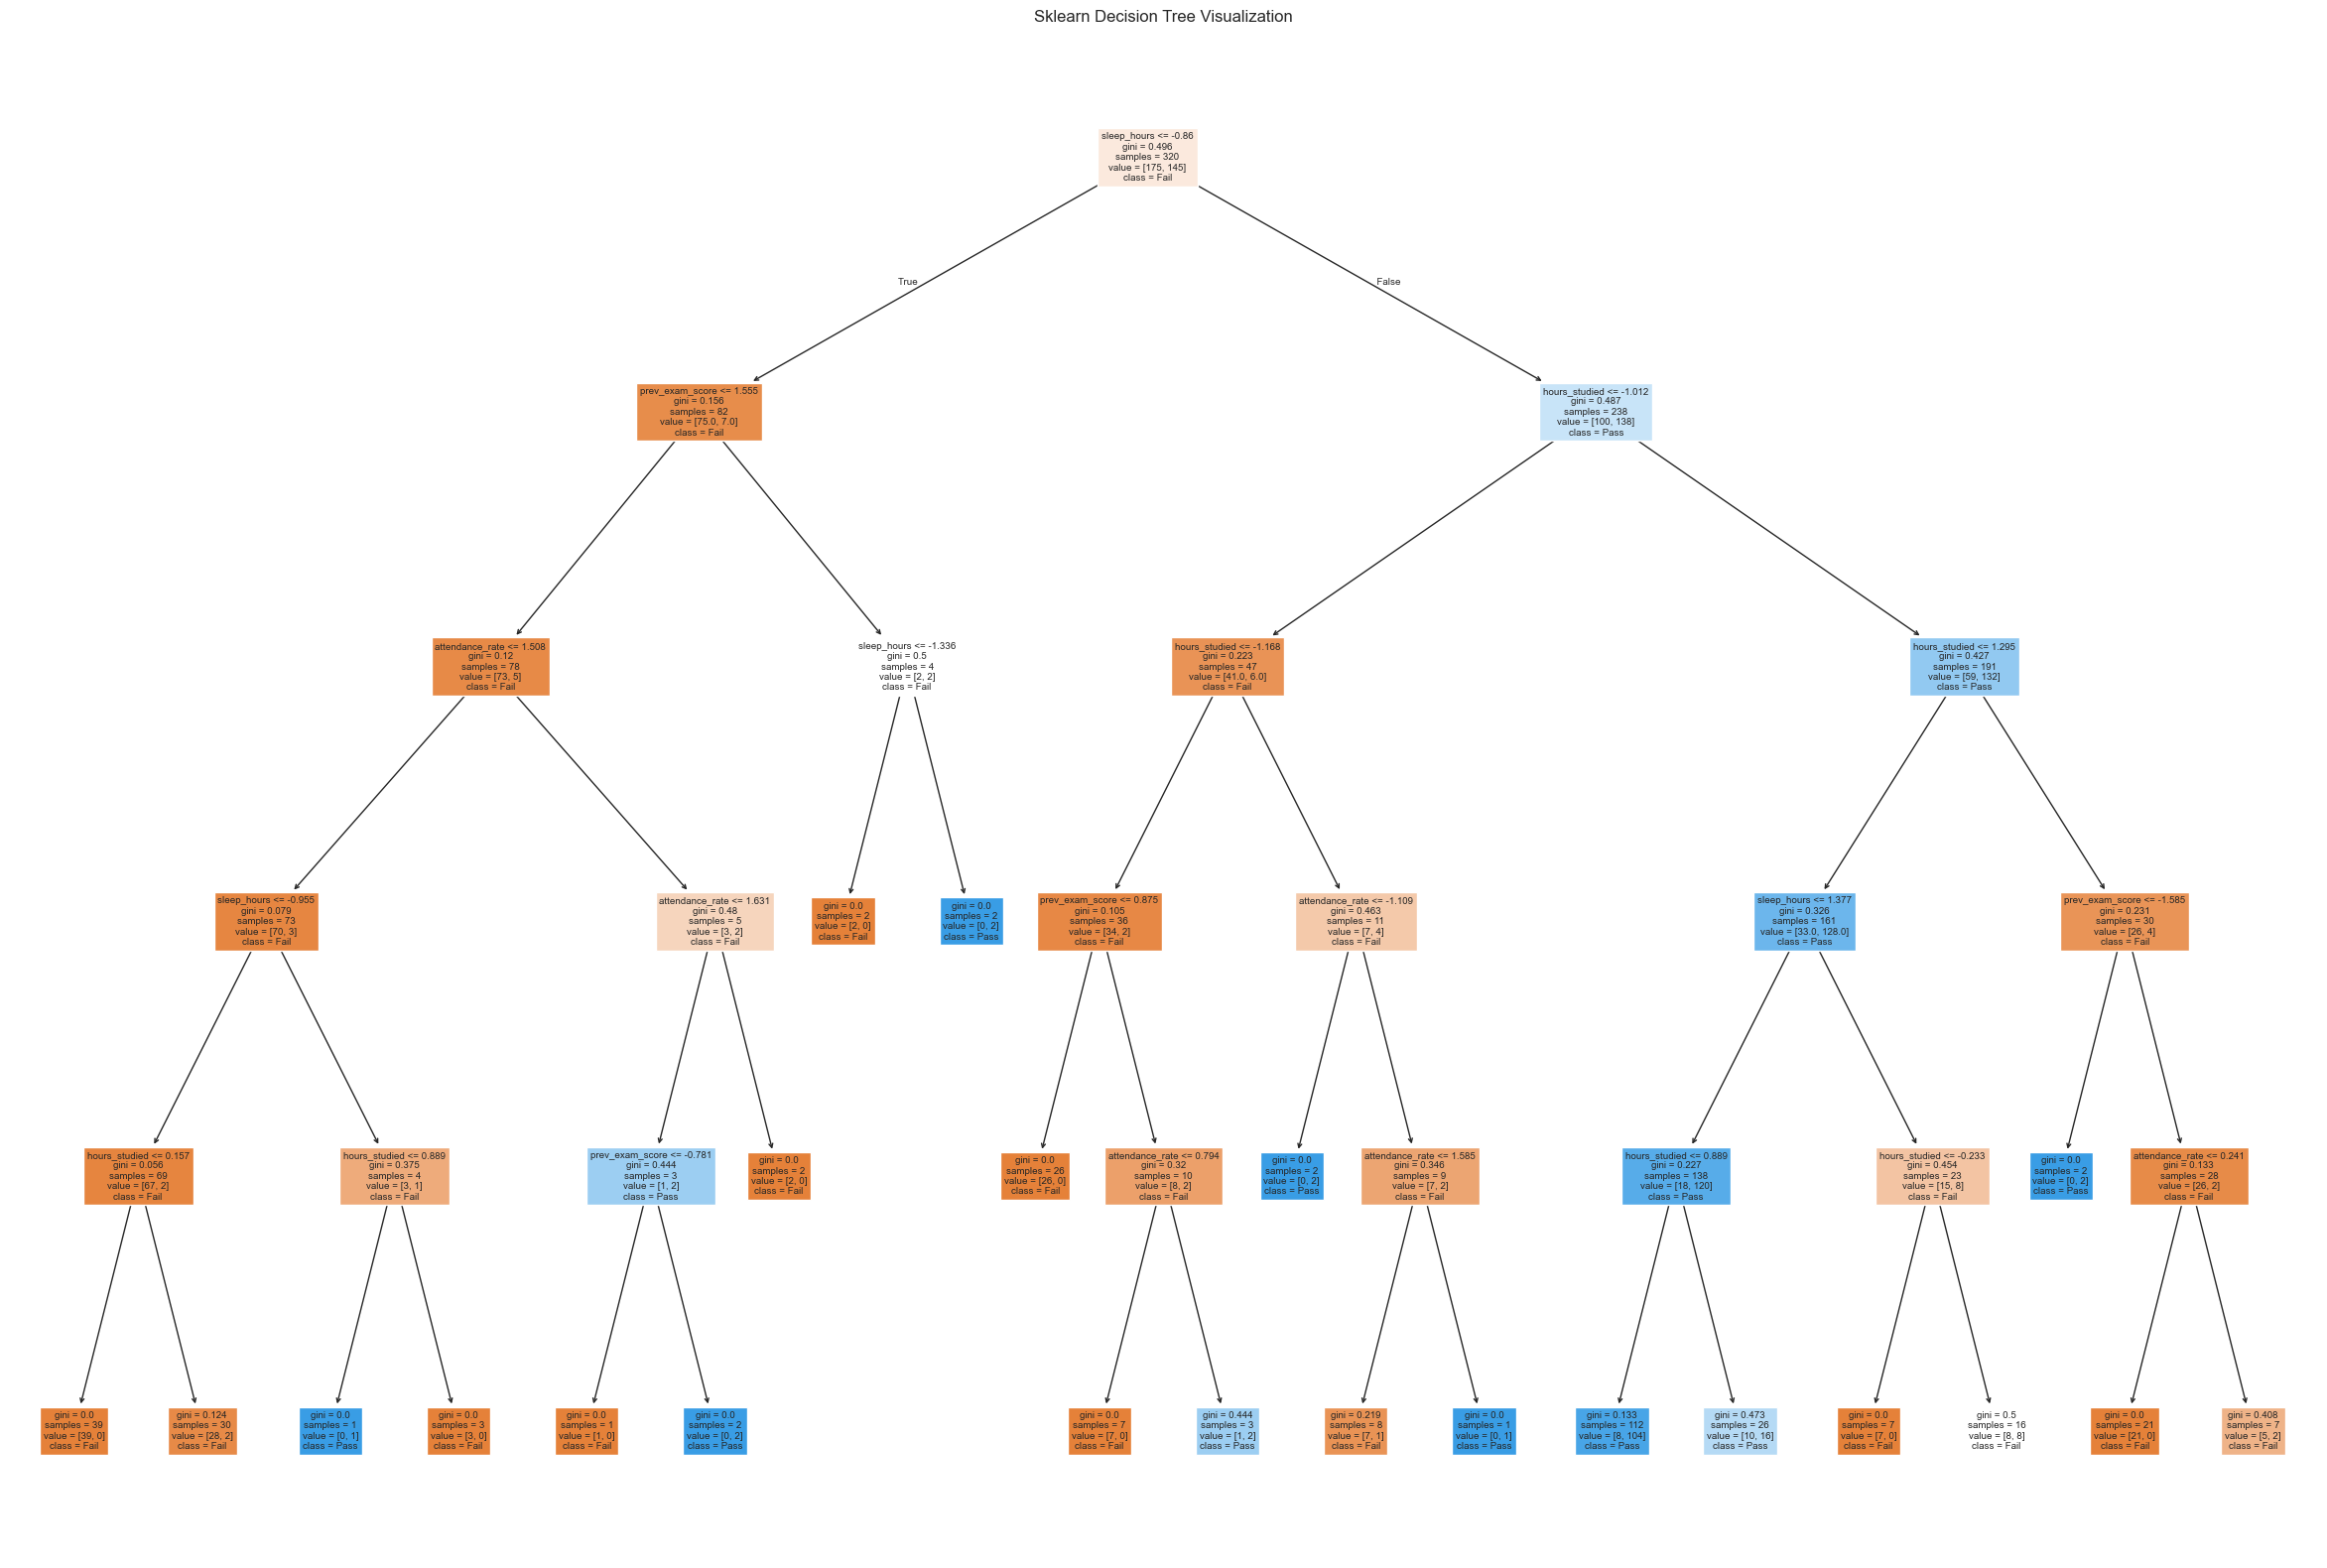


Textual Representation of Sklearn Decision Tree:

|--- sleep_hours <= -0.86
|   |--- prev_exam_score <= 1.56
|   |   |--- attendance_rate <= 1.51
|   |   |   |--- sleep_hours <= -0.96
|   |   |   |   |--- hours_studied <= 0.16
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- hours_studied >  0.16
|   |   |   |   |   |--- class: 0
|   |   |   |--- sleep_hours >  -0.96
|   |   |   |   |--- hours_studied <= 0.89
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- hours_studied >  0.89
|   |   |   |   |   |--- class: 0
|   |   |--- attendance_rate >  1.51
|   |   |   |--- attendance_rate <= 1.63
|   |   |   |   |--- prev_exam_score <= -0.78
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- prev_exam_score >  -0.78
|   |   |   |   |   |--- class: 1
|   |   |   |--- attendance_rate >  1.63
|   |   |   |   |--- class: 0
|   |--- prev_exam_score >  1.56
|   |   |--- sleep_hours <= -1.34
|   |   |   |--- class: 0
|   |   |--- sleep_hours >  -1.34
|   |   |   |--- class: 1
|--- sl

In [ ]:
# Initialize and train the decision tree


sk_tree = DecisionTreeClassifier(max_depth=5, criterion='gini', random_state=42)
sk_tree.fit(train_zscore.values, y.values)

# Compare accuracies
sk_train_accuracy = sk_tree.score(train_zscore.values, y.values) * 100
print("\nScikit-learn Decision Tree Training Accuracy: {:.2f}%".format(sk_train_accuracy))
print("\nNumpy Decision Tree Training Accuracy: {:.2f}%".format(np.mean(real_predictions == y.values)*100))

#sklearn.tree.plot_tree(sk_tree, feature_names=selected_features, class_names=['Fail', 'Pass'], filled=True)
# Decision Tree Visualization
# Used plt instead of sklearn's built in plot_tree due to visibility issues
plt.figure(figsize=(30,20))
plot_tree(sk_tree, feature_names=selected_features, class_names=['Fail', 'Pass'], filled=True)
plt.title("Sklearn Decision Tree Visualization")
plt.show()
# Textual representation of the tree
print("\nTextual Representation of Sklearn Decision Tree:\n")
print(export_text(sk_tree, feature_names=selected_features))




Quality: 
My NumPy implementation and the sklearn implementation produced the same accuracy. The feature which sklearn selects as the root split is the same when compared to the NumPy implementation. The sklearn and NumPy implementations use sleep_hours as the root node. 

## 3.3 Overfitting Analysis

The code below will train decision trees at multiple depths using sklearn's DecisionTreeClassifies and will use the cross_val_score. 

,Max Depth,Training Accuracy,CV Accuracy
0,1,0.665625,0.612500
1,2,0.775000,0.715625
2,3,0.850000,0.765625
3,5,0.900000,0.740625
4,10,0.993750,0.715625
5,None,1.000000,0.731250


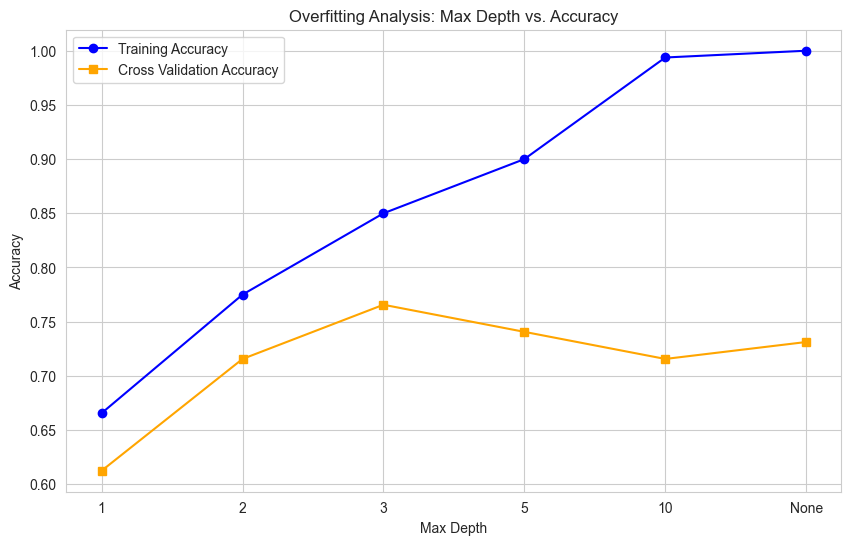

In [ ]:
depths = [1, 2, 3, 5, 10, None]
dt_train_accuracies = []
cross_validation_accuracies = []

for depth in depths:
    # Initialize model
    decision_tree = DecisionTreeClassifier(max_depth=depth, criterion='gini', random_state=42)

    # Calculates training accuracy
    decision_tree.fit(train_zscore, y)
    dt_train_accuracy = decision_tree.score(train_zscore, y)
    # Adds result to array
    dt_train_accuracies.append(dt_train_accuracy)

    # Calculate Cross Validation
    cross_validation_score = cross_val_score(decision_tree, train_zscore, y, cv=5)
    cross_validation_accuracies.append(cross_validation_score.mean())

# Print Results
display_depths = [str(d) if d is not None else "None" for d in depths]
dt_table = pd.DataFrame({
    'Max Depth': display_depths,
    'Training Accuracy': dt_train_accuracies,
    'CV Accuracy': cross_validation_accuracies
})
display(dt_table)

# Plot Graph
# Max Depth vs Accuracy
plt.figure(figsize=(10, 6))
plt.plot(display_depths, dt_train_accuracies, label='Training Accuracy', marker='o', color='blue')
plt.plot(display_depths, cross_validation_accuracies, label='Cross Validation Accuracy', marker='s', color='orange')
plt.title("Overfitting Analysis: Max Depth vs. Accuracy")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


    

Quality:
The overfitting begins at depth 5, where the gap between the training accuracy and the cross validation accuracy widens. However, the gap slightly decreases when the depth is None. 

# 4. Support Vector Machine

## 4.1 Linear SVM vs. Kernel SVM

The code below will implement a linear SVM and kernel SVM. The results will be compared to see which performs better


Linear SVM Accuracy: 
0.6 %

RBF Kernel SVM Accuracy: 
0.890625 %

Poly Kernel SVM Accuracy: 
0.809375


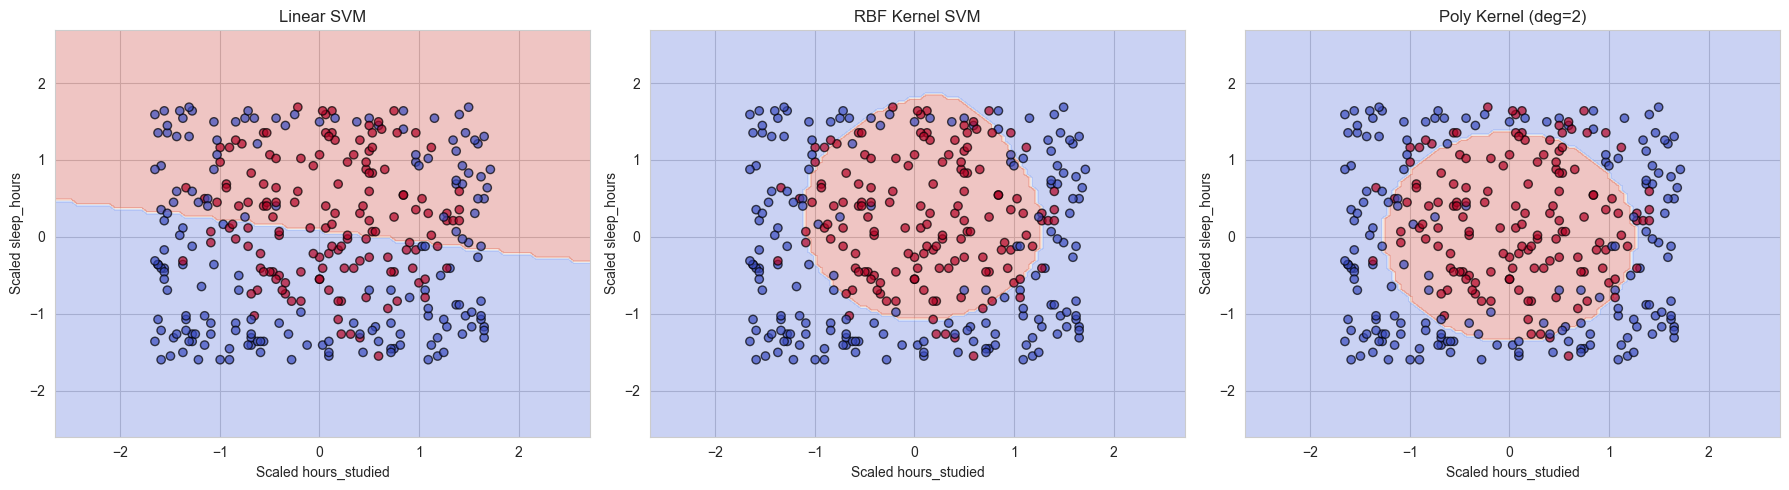

In [ ]:
# Initialize SVM models
svm_linear = SVC(kernel='linear', random_state=42)
svm_rbf = SVC(kernel='rbf', random_state=42)
svm_poly = SVC(kernel='poly', degree=2, random_state=42)

# Train models
svm_linear.fit(train_zscore, y)
svm_rbf.fit(train_zscore, y)
svm_poly.fit(train_zscore, y)

# Print Accuracies
print("\nLinear SVM Accuracy: ")
print(svm_linear.score(train_zscore, y), "%")
print("\nRBF Kernel SVM Accuracy: ")
print(svm_rbf.score(train_zscore, y), "%")
print("\nPoly Kernel SVM Accuracy: ")
print(svm_poly.score(train_zscore, y))

# Determine top 2 features for each model
important_feature_linear_svm = np.abs(svm_linear.coef_[0])
top_two_indices_linear_svm = np.argsort(importances)[-2:]
top_features = [selected_features[i] for i in top_two_indices_linear_svm]

# Assigns top 2 features to variables
feat_x_idx, feat_y_idx = top_two_indices_linear_svm[0], top_two_indices_linear_svm[1]
feat_x_name = selected_features[feat_x_idx]
feat_y_name = selected_features[feat_y_idx]

x_decision_boundary = train_zscore.iloc[:, [feat_x_idx, feat_y_idx]].values
y_decision_boundary = y.values


# Plot Decision Boundary visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models_vis = [
    (SVC(kernel='linear', random_state=42), "Linear SVM"),
    (SVC(kernel='rbf', random_state=42), "RBF Kernel SVM"),
    (SVC(kernel='poly', degree=2, random_state=42), "Poly Kernel (deg=2)")
]

for ax, (model, title) in zip(axes, models_vis):
    # Retrain on just the 2 features for plotting
    model.fit(x_decision_boundary, y_decision_boundary)
    
    # Uses sklearn function to plot graph
    DecisionBoundaryDisplay.from_estimator(
        model, 
        x_decision_boundary, 
        response_method="predict",
        cmap="coolwarm", 
        alpha=0.3, 
        ax=ax,
        xlabel=f"Scaled {feat_x_name}",
        ylabel=f"Scaled {feat_y_name}"
    )
    
    # Plot the original scatter points on top
    ax.scatter(x_decision_boundary[:, 0], x_decision_boundary[:, 1], c=y_decision_boundary, edgecolors='k', cmap='coolwarm', alpha=0.7)
    ax.set_title(title)

plt.tight_layout()
plt.show()






Quality:
The RBF Kernel SVM performs the best out of all the other SVMs. This performance is a result of the data not being linearly separable, making it much harder for a linear model to be accurate. Moreover, the RBF kernel SVM plots the data into a higher dimensional space so that the data is linearly separable. This is done using the inner products of the vectors. This technique is called the kernel trick and allows for data that is not linearly separable to be classified using linear classification

## 4.2 Hyperparameter Tuning (C and kernel)

In this code below, the C parameter will be tuned for the RBF Kernel, since it was the highest performing SVM.

CV Accuracies (holding gamma = 0.1)
C Value  | CV Accuracy
C = 0.01 | 54.69%
C = 0.1  | 60.31%
C = 1.0  | 84.06%
C = 10.0 | 85.94%
C = 100.0 | 84.38%

Best Parameters Found: {'C': 10, 'gamma': 0.1}

Best Cross-Validation Accuracy: 85.9375


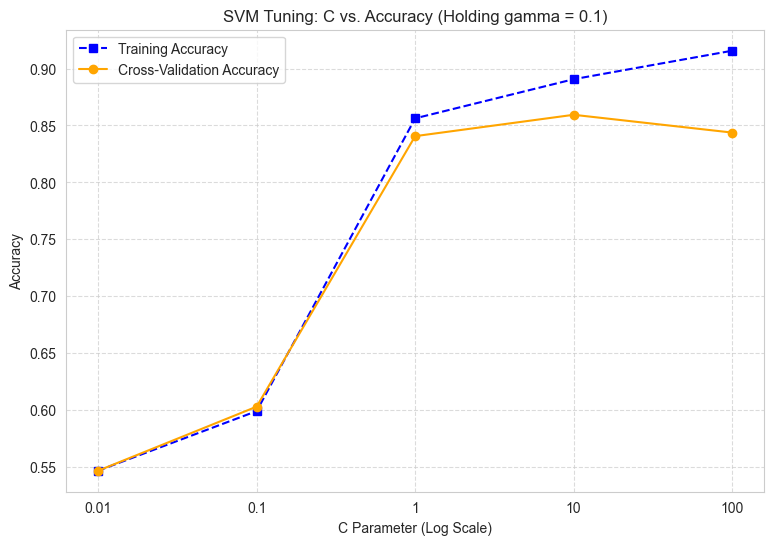

In [ ]:
# Best Kernel was RBF so it will be used for this part
svm_hyperparameter = SVC(kernel='rbf', random_state=42)

parameter_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'gamma': ['scale', 0.01, 0.1, 1, 10]
}

grid_search = GridSearchCV(svm_hyperparameter, parameter_grid, cv=5, return_train_score=True)
grid_search.fit(train_zscore, y)

# Extract results
cv_results = pd.DataFrame(grid_search.cv_results_)
best_gamma = grid_search.best_params_['gamma']

best_gamma_results = cv_results[cv_results['param_gamma'] == best_gamma]


print(f"CV Accuracies (holding gamma = {best_gamma})")
print("C Value  | CV Accuracy")
for index, row in best_gamma_results.iterrows():
    c_val = row['param_C']
    # 'mean_test_score' is the Scikit-Learn term for Cross-Validation Accuracy
    cv_acc = row['mean_test_score'] * 100 
    print(f"C = {c_val:<4} | {cv_acc:.2f}%")


print(f"\nBest Parameters Found: {grid_search.best_params_}")
print(f"\nBest Cross-Validation Accuracy: {grid_search.best_score_ *100}")

plt.figure(figsize=(9, 6))
plt.semilogx(best_gamma_results['param_C'], best_gamma_results['mean_train_score'], 
             marker='s', label='Training Accuracy', linestyle='--', color='blue')
plt.semilogx(best_gamma_results['param_C'], best_gamma_results['mean_test_score'], 
             marker='o', label='Cross-Validation Accuracy', color='orange')

plt.title(f"SVM Tuning: C vs. Accuracy (Holding gamma = {best_gamma})")
plt.xlabel("C Parameter (Log Scale)")
plt.ylabel("Accuracy")
plt.xticks([0.01, 0.1, 1, 10, 100], labels=['0.01', '0.1', '1', '10', '100'])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Quality:
The effect of C when it is very small is that it creates much wider trade off margin, meaning that it accepts more misclassifications, which could lead to underfitting. On the contrast, a very high value for C results in strict classification, which could also result in an overfitting risk.

# 5. Random Forest

## 5.1 Training and OOB Evaluation

The code below will create a random forest. The results will be compared against a single decision tree.

Random Forest (100 trees) - Training Accuracy: 100.0%
Random Forest (100 trees) - OOB Accuracy: 84.0625%
Random Forest (100 trees) - Test Accuracy: 82.5%


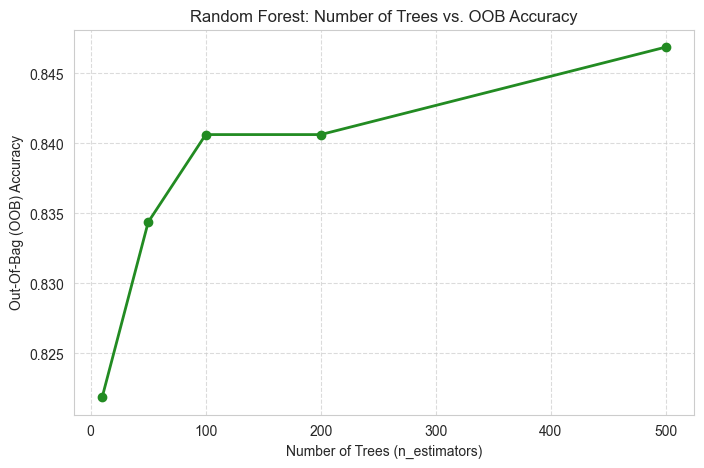

In [ ]:
# Train model
random_forest_model = RandomForestClassifier(n_estimators=100, oob_score=True, random_state=42)
random_forest_model.fit(train_zscore, y)

# Calculate Accuracies
rf_train_accuracy = random_forest_model.score(train_zscore, y)
rf_test_accuracy = random_forest_model.score(test_zscore, y_test)
rf_oob_accuracy = random_forest_model.oob_score_

# Print results
print(f"Random Forest (100 trees) - Training Accuracy: {rf_train_accuracy * 100}%")
print(f"Random Forest (100 trees) - OOB Accuracy: {rf_oob_accuracy * 100}%")
print(f"Random Forest (100 trees) - Test Accuracy: {rf_test_accuracy * 100}%")

# Experiment with n_estimators
n_estimators = [10, 50, 100, 200, 500]
oob_scores = []

# Creates a tree and stores result for each n_estimator
for num in n_estimators:
    rf = RandomForestClassifier(n_estimators=num, oob_score=True, random_state=42)
    rf.fit(train_zscore, y)
    oob_scores.append(rf.oob_score_)

# Plot Comparison Graph
plt.figure(figsize=(8, 5))
plt.plot(n_estimators, oob_scores, marker='o', color='forestgreen', linestyle='-', linewidth=2)
plt.title("Random Forest: Number of Trees vs. OOB Accuracy")
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Out-Of-Bag (OOB) Accuracy")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Quality: 
The random forest outperforms a single decision tree because of bagging, whihch allows the dominant feature to be excluded in certain trees. This feature results in diverse tree for each split, meaning the models have a low variance. Increasing the n_estimators does not lead to overfitting because the OOB accuracy increases as the number of trees increases. 

## 5.2 Feature Importance

The code below will identify the most important features for the random forest.


Feature Importances:


,Feature,Importance
0,hours_studied,0.417356
1,sleep_hours,0.329119
2,attendance_rate,0.130692
3,prev_exam_score,0.122833


C:\Users\gcisn\AppData\Local\Temp\ipykernel_33092\1415658448.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_table, palette='viridis')


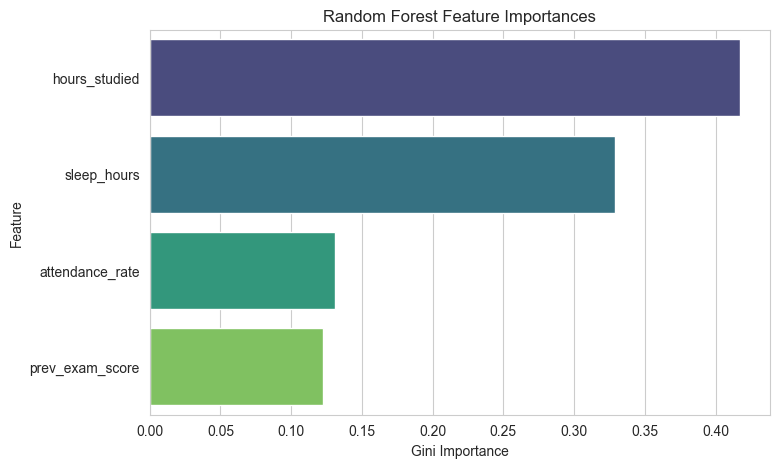

In [ ]:
importances = random_forest_model.feature_importances_

# Create table to print info
feature_imp_table = pd.DataFrame({
    'Feature': selected_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importances:")
display(feature_imp_table)

# Plot graph
plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=feature_imp_table, palette='viridis')
plt.title("Random Forest Feature Importances")
plt.xlabel("Gini Importance")
plt.ylabel("Feature")
plt.show()


Analysis:
The two most important featues based off the gini importance are hours_studied and sleep_hours. The least important feature was a student's prev_exam_score. Based off the EDA, hours_studied had one of the lowest relationship to a student's exam pass/fail rate. However, as discussed earlier, the data featured nonlinear patterns, with the inclusion of a burnout effect, where too much studying could prove detrimental to a student's pass/fail rate. The feature ranking does make sense logically, the amount of time a student spends studying would help them increase their chances of receiving a pass. The feature importance from the random forest and the root split feature from the NumPy and Sklearn implementations are different. The limitation to the built in feature importance measure is that it 

# 6. Model Comparison and Final Evaluation

In [ ]:
# Calculate final TEST accuracies
lr_test_acc = logistic_regression_model.score(test_zscore, y_test)
dt_test_acc = sk_tree.score(test_zscore.values, y_test.values) 

# grid_search.best_estimator_ is your tuned SVM from Part 4.2
svm_test_acc = grid_search.best_estimator_.score(test_zscore, y_test)
rf_test_acc = random_forest_model.score(test_zscore, y_test)

# Calculate CV accuracies (using 5-fold CV on the training data)
lr_cv = cross_val_score(logistic_regression_model, train_zscore, y, cv=5).mean()
dt_cv = cross_val_score(sk_tree, train_zscore.values, y.values, cv=5).mean()
svm_cv = cross_val_score(grid_search.best_estimator_, train_zscore, y, cv=5).mean()
rf_cv = cross_val_score(random_forest_model, train_zscore, y, cv=5).mean()

# Calculate training accuracies
lr_train_acc = logistic_regression_model.score(train_zscore, y)
dt_train_acc = sk_tree.score(train_zscore.values, y.values)
svm_train_acc = grid_search.best_estimator_.score(train_zscore, y)
rf_train_acc = random_forest_model.score(train_zscore, y)

# Createe comparison table
comparison_data = {
    'Model': [
        'Logistic Regression', 
        'Decision Tree (Best Depth = 5)', 
        'SVM (Tuned RBF)+ C = 10', 
        'Random Forest (100 Trees)'
    ],
    'Train Acc': [f"{lr_train_acc*100:.2f}%", f"{dt_train_acc*100:.2f}%", f"{svm_train_acc*100:.2f}%", f"{rf_train_acc*100:.2f}%"],
    'CV Acc': [f"{lr_cv*100:.2f}%", f"{dt_cv*100:.2f}%", f"{svm_cv*100:.2f}%", f"{rf_cv*100:.2f}%"],
    'Test Acc': [f"{lr_test_acc*100:.2f}%", f"{dt_test_acc*100:.2f}%", f"{svm_test_acc*100:.2f}%", f"{rf_test_acc*100:.2f}%"]
}

comparison_df = pd.DataFrame(comparison_data)
print("\nFinal Model Comparison Table:")
display(comparison_df)


Final Model Comparison Table:


,Model,Train Acc,CV Acc,Test Acc
0,Logistic Regression,55.94%,55.62%,58.75%
1,Decision Tree (Best Depth = 5),90.00%,74.06%,82.50%
2,SVM (Tuned RBF)+ C = 10,88.75%,85.94%,85.00%
3,Random Forest (100 Trees),100.00%,81.88%,82.50%


# 7. Summary & Reflection

The model that performed best on the test and train dataset differed. For the test dataset, the best model was the RBF kernel SVM. The model that performed the best on the train dataset was the random forest with 100 trees. The RBF SVM performed the best on the test dataset because of the kernel trick, where the data’s features are mapped in a higher dimensionality, resulting in a classification line that is much more accurate. Moreover, the importance of the higher dimensionality increases because the data is nonlinear, making it hard for a linear model to create an accurate classification line. For instance, the logistic regression model had a 55% accuracy on the train dataset and cross fold validation and 58% test accuracy. These results are very poor when compared to the RBF SVM where it achieved an 85% accuracy on the test dataset. The data was nonlinear and had a built in burnout effect with the hours_studied feature. Thus, the linear models such as logistic regression and the linear SVM struggled to create accurate results. The most surprising find in my analysis was the kernel trick in action. From the EDA it was very evident that the data was nonlinear, however, using a linear classifier to still separate the data was very interesting to see happening. If the project had more time to improve performance, I would have attempted different data imputations, such as dropping rows with missing values and replacing outliers with more reasonable data.  This difference could lead to different and perhaps more accurate results. Moreover, I would create a random forest with a higher number of trees, to see what the highest accuracy the model would be able to reach. As a result of bagging, the random forest model could reach a higher accuracy with more trees. The only downside would be the training and computation costs, which would increase as a result of a higher number of trees. The bias-variance trade off across models can be exemplified with the decision trees and the random forest. The decision tree would suffer with high variance at depth of 5, where the training accuracy would increase but the cross validation accuracy decreased. These results demonstrated the effects of variance that lead to an overfitting model. On the other hand, the random forest was able to lower the variance through bagging and was able to achieve great results on the training dataset.